In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

Создаем новый признак ошиибка баланса,так как мошенники могут сразу обналичивать и деньги даже не дойдут до мерчанта,
как мы видим на графике у мошенников эта метрика намного выше.

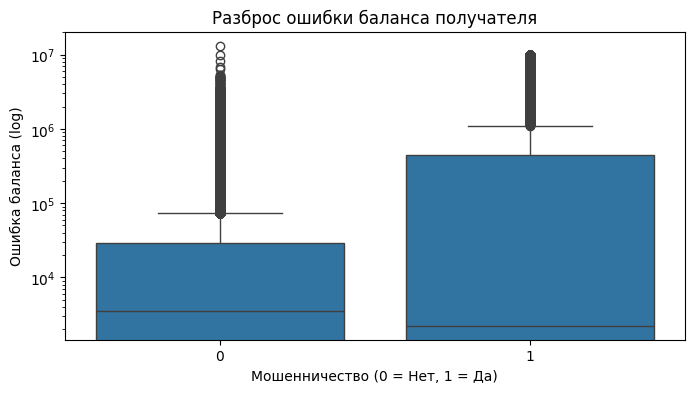

In [4]:
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
plt.figure(figsize=(8,4))
sns.boxplot(x='isFraud', y='errorBalanceDest', data=df)
plt.yscale('log') # Без логарифма график будет нечитаемым из-за выбросов
plt.title('Разброс ошибки баланса получателя')
plt.xlabel('Мошенничество (0 = Нет, 1 = Да)')
plt.ylabel('Ошибка баланса (log)')

plt.show()


Проверим гипотезу о том что мошенники зачастую совершают операции ночью.Исходя из графика и из выведенего среднего процента фрода видимм ,что мошенников больше в ночное время

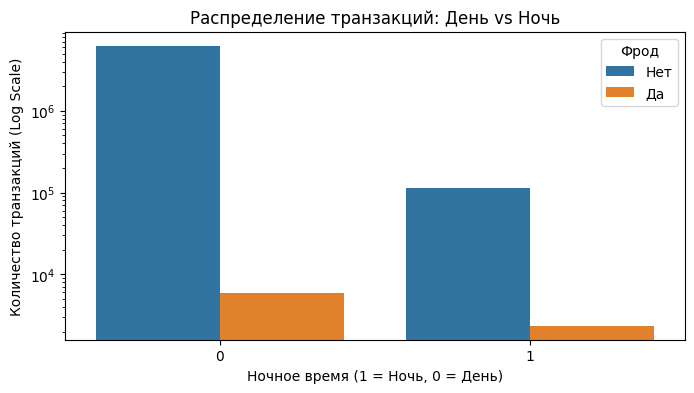

In [5]:
df["hour"] = df["step"] %24
df["night_time"] = ((df["hour"]>=0) & (df["hour"]<=6)).astype(int)

plt.figure(figsize=(8, 4))
sns.countplot(x='night_time', hue='isFraud', data=df)

plt.yscale('log') # Здесь логарифм полезен, так как обычных транзакций МИЛЛИОНЫ, а фрода мало
plt.title('Распределение транзакций: День vs Ночь')
plt.xlabel('Ночное время (1 = Ночь, 0 = День)')
plt.ylabel('Количество транзакций (Log Scale)')
plt.legend(title='Фрод', labels=['Нет', 'Да'])
plt.show()

In [6]:
print("Процент фрода:")
print(df.groupby('night_time')['isFraud'].mean()*100)

Процент фрода:
night_time
0    0.093795
1    2.028873
Name: isFraud, dtype: float64


Создаем матрицу корреляции признаков,для нашего класса таргета не большие коэффиценты корреляции,но это нормально,так как присутствует дисбаланс классов

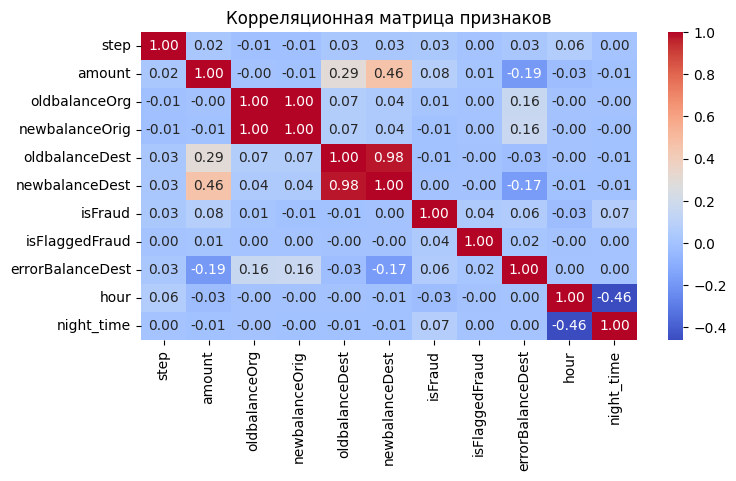

In [7]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,4))
sns.heatmap(data=corr_matrix,cmap="coolwarm",fmt =".2f",annot=True)
plt.title('Корреляционная матрица признаков')
plt.show()

Разбиваем данный,важно использовать stratify при дисбалансе,чтобы в тестовой выборке тоже были нужные предметы классов.
Обучаем модель и видим,что мы поймали почти всех мошенников,но так же заблокировали множество честных клиентов,
это нам не подходит нужно будет менять порог определения класса для максимизации precision

In [8]:
features = [
    'step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'hour', 'night_time'
]

X = df[features]
y = df['isFraud']

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y,test_size=0.2)

model = CatBoostClassifier(iterations=500,learning_rate=0.1,auto_class_weights='Balanced',cat_features=["type"])
model.fit(X_train,y_train,verbose=100)
y_pred = model.predict(X_test)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")



0:	learn: 0.5072798	total: 1.76s	remaining: 14m 38s
100:	learn: 0.0191963	total: 2m 24s	remaining: 9m 30s
200:	learn: 0.0100878	total: 4m 38s	remaining: 6m 53s
300:	learn: 0.0063876	total: 7m	remaining: 4m 38s
400:	learn: 0.0053366	total: 8m 56s	remaining: 2m 12s
499:	learn: 0.0052773	total: 10m 10s	remaining: 0us
Precision: 0.3116
Recall: 0.9945
F1 Score: 0.4745
ROC AUC Score: 0.9958


Подобрали наилучший порог для f1

In [9]:
thresholds = np.linspace(0, 1, 100)
probs = model.predict_proba(X_test)[:, 1]
f1_scores = [f1_score(y_test, probs > t) for t in thresholds]
# Находим порог с лучшим F1
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Математически оптимальный порог: {best_thresh:.4f}")

Математически оптимальный порог: 0.9899


Использовали наилучший порог для определения мошенников и получили вот такие метрики,да мы стали покрывать не всех мошенников,но ситуация с блокировками честных клиентов сильно улучшилась

In [65]:
probs = model.predict_proba(X_test)[:, 1]
y_pred_threshold = (probs >= best_thresh).astype(int)
precision = precision_score(y_test,y_pred_threshold)
recall = recall_score(y_test,y_pred_threshold)
f1 = f1_score(y_test,y_pred_threshold)
roc_auc = roc_auc_score(y_test,y_pred_threshold)
print(f"метрики после изменения порога вероятности на {best_thresh:.4f}")
print(f"Precision: {precision:.4f}, recall: {recall:.4f}, f1score: {f1:.4f}, rocauc: {roc_auc:.4f}")


метрики после изменения порога вероятности на 0.9899
Precision: 0.9321, recall: 0.8947, f1score: 0.9130, rocauc: 0.9473


Вывели какие признаки внесли больше всего информаии для модели,хоть наши исследования и показали , что night_time будет хорошим признаком модель не обратила на него внимание,
так как нужную информацию она уже взяла из колонки hour так как они коррелируют

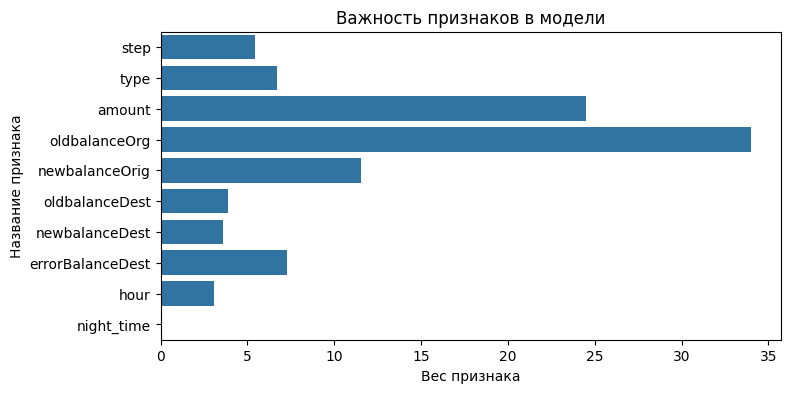

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=model.get_feature_importance(), 
    y=X_train.columns
)

plt.title('Важность признаков в модели')
plt.xlabel('Вес признака')
plt.ylabel('Название признака')
plt.show()

Построили матрицу ошибок,видим сколько ошибок по клиентма мы соврешили

<Figure size 800x600 with 0 Axes>

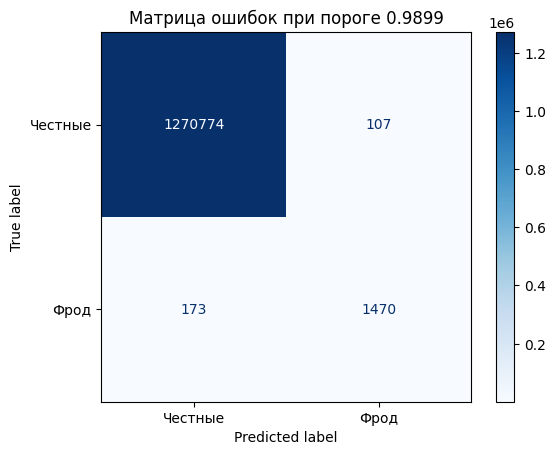

In [71]:
cm = confusion_matrix(y_test, y_pred_threshold)

# 3. Визуализируем
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Честные', 'Фрод'])
disp.plot(cmap='Blues', values_format='d')

plt.title(f'Матрица ошибок при пороге {best_thresh:.4f}')
plt.show()

Решил заместо auto_class_weight в catboost попробовать adasyn. Adasyn генерирует синтетические данные для модели в тех местах где ей сложно.
Главное было не допустить синтеческих данных в тестовую выборку


In [75]:
from imblearn.over_sampling import ADASYN
ada = ADASYN(random_state=42)
X_numeric = pd.get_dummies(X_train,columns=["type"])
X_res, y_res = ada.fit_resample(X_numeric, y_train)
print(f"Размеры до {y_train.shape},Размеры после ADASYN: {y_res.shape}")

Размеры до (5090096,),Размеры после ADASYN: (10167945,)


In [ ]:
model_ada = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    verbose=100
)

model_ada.fit(X_res, y_res)
# Предсказываем на реальном тесте тоже переведенном 
X_test_numeric = pd.get_dummies(X_test)
#важно убедиться что колонки совпадают
X_test_numeric = X_test_numeric.reindex(columns=X_numeric.columns, fill_value=0)

probs_ada = model_ada.predict_proba(X_test_numeric)[:, 1]

0:	learn: 0.4967152	total: 769ms	remaining: 6m 23s
100:	learn: 0.0229741	total: 1m 17s	remaining: 5m 6s
200:	learn: 0.0143395	total: 2m 44s	remaining: 4m 4s
300:	learn: 0.0103610	total: 4m 7s	remaining: 2m 43s
400:	learn: 0.0088241	total: 5m 24s	remaining: 1m 20s
499:	learn: 0.0071882	total: 6m 49s	remaining: 0us


In [78]:
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test, probs_ada > t) for t in thresholds]
# Находим порог с лучшим F1
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Математически оптимальный порог: {best_thresh:.4f}")


Математически оптимальный порог: 0.9899


Метрика precision улучшилась,а recall упала. На самом деле разница по метрикам еле заметно, нельзя сказать где лучше.
Но где мы просто использовали праметр auto_class_weight Catboost легче и не будет создавать лишний шум как adasyn,поэтому мы выбираем простую модель catboost

In [79]:
y_pred_threshold = (probs_ada >= best_thresh).astype(int)
precision = precision_score(y_test,y_pred_threshold)
recall = recall_score(y_test,y_pred_threshold)
f1 = f1_score(y_test,y_pred_threshold)
roc_auc = roc_auc_score(y_test,y_pred_threshold)
print(f"метрики после изменения порога вероятности на {best_thresh:.4f}")
print(f"Precision: {precision:.4f}, recall: {recall:.4f}, f1score: {f1:.4f}, rocauc: {roc_auc:.4f}")


метрики после изменения порога вероятности на 0.9899
Precision: 0.9401, recall: 0.8691, f1score: 0.9032, rocauc: 0.9345


In [10]:
# Сохраняем модель для деплоя. 
# CatBoost сохраняет и структуру деревьев, и параметры категориальных фичей.
model.save_model("best_fraud_model.cbm")
loaded_model = CatBoostClassifier()
loaded_model.load_model("best_fraud_model.cbm")
print("Модель успешно сохранена")

Модель успешно сохранена и готова к деплою!
